# Multiscaling & growth tent across graph topologies

For each degree distribution, averaged over **20 realizations**, measure:

1. the **first four multiscaling exponents** $\zeta_1,\dots,\zeta_4$, where
   $E[\sigma^q\mid S]\sim S^{-\zeta_q}$ on the decline branch ($\zeta_1=\beta$);
2. the **multiscaling verification** — $\zeta_q/\zeta_1$ vs $q$, against the granular flat
   prediction ($1,1,1,1$) and the MSB data ($1,2.0,2.6,2.9$);
3. the **growth-rate distribution** (the tent), pooled, vs Gaussian and Laplace.

Everything held fixed except the degree distribution: own-degree normalization, matched mean
degree $C=100$, locked operating point $\mu=1.76,\sigma=1.75,\lambda=10^{-3}$. Twenty seeds so
the heavy-tailed topologies (whose $\beta$ is realization-noisy at few seeds) get a real average
with bootstrap-over-economy error bars, not a spurious single-draw value.

> **pl2.5 is the thesis model.** The hand-rolled builder here reproduces
> `coupling(kind="powerlaw_owndeg")` bit-for-bit, so the pl2.5 column is the thesis code exactly;
> the sparse variants change only the degree draw. **fc** (fully-connected, dense Gaussian couplings —
> the ensemble DMFT is derived for) is the *no-topology* limit: does the multiscaling need the sparse
> structure at all, or survive in pure dense disorder?

In [1]:
import os, sys
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
import networkx as nx
from scipy import sparse
from scipy.stats import laplace
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility, tent_stats, rescale

SMOKE = os.environ.get("TOPO_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3          # locked own-degree operating point
C = 100                                     # matched mean degree across topologies
N, SEEDS = (600, 4) if SMOKE else (2000, 20)
TMAX, N_EVAL = (100.0, 400) if SMOKE else (300.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (230.0, 290.0)), 0.5
NB, NJOBS = 20, 8
TOPOS = ["regular", "exponential", "pl2.5", "pl3.5", "fc"]
print(f"{'SMOKE ' if SMOKE else ''}N={N} x {SEEDS} seeds x {len(TOPOS)} topologies  "
      f"mu={MU} sigma={SIGMA} lam={LAM}  window={LATE}")

N=2000 x 20 seeds x 5 topologies  mu=1.76 sigma=1.75 lam=0.001  window=(230.0, 290.0)


In [2]:
def degree_seq(topo, N, rng):
    """Degree sequence, mean ~C; topologies differ only in tail / variance."""
    if topo == "regular":
        return np.full(N, C, float)                          # zero degree variance
    if topo == "exponential":
        return np.maximum(rng.exponential(C, N), 1.0)        # finite var ~C^2, light tail
    a = 2.5 if topo == "pl2.5" else 3.5                      # pl2.5 infinite var; pl3.5 finite var
    kmin = C * (a - 2) / (a - 1)                             # sets mean = C
    return np.maximum(kmin * (1 - rng.uniform(size=N)) ** (-1 / (a - 1)), 1.0)

def owndeg_alpha(topo, N, mu, sigma, seed):
    # EXACT mirror of coupling()'s powerlaw_owndeg path (verified bit-identical for pl2.5):
    # single rng stream, draw degrees then couplings; own-degree normalization a_ij = mu/k_i + sigma/sqrt(k_i) z.
    rng = np.random.default_rng(seed)
    deg = np.maximum(np.round(degree_seq(topo, N, rng)).astype(int), 1)
    if deg.sum() % 2:
        deg[deg.argmin()] += 1
    G = nx.Graph(nx.configuration_model(deg.tolist(), seed=int(seed)))
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    ki = np.diff(A.indptr).astype(float); ki[ki == 0] = 1.0
    coo = A.tocoo()
    z = rng.normal(size=coo.row.size)
    vals = mu / ki[coo.row] + (sigma / np.sqrt(ki[coo.row])) * z
    return sparse.csr_array((vals, (coo.row, coo.col)), shape=(N, N)), ki

def run(topo, seed):
    """One economy -> per-survivor size/vol/growth + degree anchors, or None if it froze."""
    if topo == "fc":
        alpha = coupling(N, MU, SIGMA, kind="fc", seed=seed)     # dense, no topology (DMFT ensemble)
        ki = np.full(N, N - 1, float)                            # every firm coupled to all others
    else:
        alpha, ki = owndeg_alpha(topo, N, MU, SIGMA, seed)
    r = integrate(alpha, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
    if sv["growth"].size == 0 or not np.isfinite(sv["beta"]):
        return None
    return dict(topo=topo, seed=seed, Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"],
                beta=sv["beta"], kmean=float(ki.mean()), kcv=float(ki.std() / ki.mean()),
                kmax=float(ki.max()))

In [3]:
def multiscaling(Sbar, vol, econ, nb=NB, nboot=200):
    """zeta_1..4 from E[sigma^q|S]~S^-zeta_q on the decline branch + bootstrap-over-economy errors.
    Mirrors scripts/msb_conditional.py."""
    live = (vol > 0) & np.isfinite(vol) & (Sbar > 0)
    Sbar, vol, econ = Sbar[live], vol[live], econ[live]
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by)); Scut = bx[pk]; dec = Sbar > Scut
    nfit = max(6, nb - pk)
    def cq_of(Sx, vx):
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
        bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []; D2 = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px]); D2.append(byy)
            mm = (bxx > 0) & (byy > 0)
            out.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
        return np.array(out), bxx, np.array(D2)
    cq, bxd, D2M = cq_of(Sbar[dec], vol[dec])
    ue = np.unique(econ[dec]); rbs = np.random.default_rng(0); boot = []
    if ue.size >= 2:
        for _ in range(nboot):
            pick = rbs.choice(ue, ue.size, replace=True)
            ix = np.concatenate([np.where(econ[dec] == e)[0] for e in pick])
            boot.append(cq_of(Sbar[dec][ix], vol[dec][ix])[0])
        boot = np.array(boot); cq_err = boot.std(0); ratio_err = (boot / boot[:, [0]]).std(0)
    else:
        cq_err = np.full(4, np.nan); ratio_err = np.full(4, np.nan)
    return dict(cq=cq, cq_err=cq_err, ratio=cq / cq[0], ratio_err=ratio_err,
                bxd=bxd, D2M=D2M, Scut=float(Scut), ndec=int(dec.sum()))

In [4]:
# ---- run all topologies x seeds in one pool, then group -------------------------------------
import time
t0 = time.time()
jobs = [(t, s) for t in TOPOS for s in range(SEEDS)]
out = Parallel(n_jobs=NJOBS, backend="loky")(delayed(run)(t, s) for t, s in jobs)
out = [x for x in out if x is not None]
print(f"integrated in {(time.time()-t0)/60:.1f} min; {len(out)}/{len(jobs)} economies survived\n")

results = {}
for topo in TOPOS:
    recs = [x for x in out if x["topo"] == topo]
    if len(recs) < 2:
        print(f"{topo:<12} only {len(recs)} survived — skipped"); continue
    Sbar = np.concatenate([x["Sbar"] for x in recs])
    vol = np.concatenate([x["vol"] for x in recs])
    growth = np.vstack([x["growth"] for x in recs])
    econ = np.concatenate([np.full(x["Sbar"].size, x["seed"]) for x in recs])
    ms = multiscaling(Sbar, vol, econ)
    ts = tent_stats(growth)
    results[topo] = dict(ms=ms, ts=ts, gz=rescale(growth), nsurv=len(recs),
                         kmean=np.median([x["kmean"] for x in recs]),
                         kcv=np.median([x["kcv"] for x in recs]),
                         kmax=np.median([x["kmax"] for x in recs]),
                         beta_each=np.array([x["beta"] for x in recs]))

integrated in 1.3 min; 100/100 economies survived



In [5]:
# ---- results table --------------------------------------------------------------------------
print(f"{'topology':<12}{'surv':>5}{'meanK':>7}{'CV':>6}{'kmax':>7}   "
      f"{'z1=beta':>18}{'z2':>10}{'z3':>10}{'z4':>10}   {'bowley':>7}{'exk':>6}")
for t in TOPOS:
    if t not in results: continue
    R = results[t]; c, e = R["ms"]["cq"], R["ms"]["cq_err"]
    beta_sd = R["beta_each"].std()
    print(f"{t:<12}{R['nsurv']:>5}{R['kmean']:>7.0f}{R['kcv']:>6.2f}{R['kmax']:>7.0f}   "
          f"{c[0]:>7.2f}±{e[0]:<4.2f}(sd{beta_sd:.2f})"
          f"{c[1]:>7.2f}±{e[1]:<3.2f}{c[2]:>7.2f}±{e[2]:<3.2f}{c[3]:>7.2f}±{e[3]:<3.2f}   "
          f"{R['ts']['bowley']:>+7.2f}{R['ts']['exkurt']:>6.1f}")
print("\nmultiscaling ratios zeta_q/zeta_1  (granular flat: 1,1,1,1 ; MSB data: 1, 2.0, 2.6, 2.9)")
for t in TOPOS:
    if t not in results: continue
    r = results[t]["ms"]["ratio"]
    print(f"  {t:<12} " + "  ".join(f"{v:.2f}" for v in r))

topology     surv  meanK    CV   kmax              z1=beta        z2        z3        z4    bowley   exk
regular        20     98  0.02    100      0.85±0.03(sd0.05)   1.63±0.07   2.30±0.12   2.85±0.16     -0.06  17.1
exponential    20     91  0.91    568      0.82±0.06(sd0.16)   1.43±0.17   1.75±0.34   1.86±0.54     -0.14  31.9
pl2.5          20     77  1.24   1594      0.80±0.04(sd0.07)   1.46±0.10   1.97±0.19   2.31±0.30     -0.12  24.3
pl3.5          20     95  0.60    870      0.82±0.03(sd0.04)   1.54±0.07   2.13±0.12   2.54±0.18     -0.05  15.6
fc             20   1999  0.00   1999      0.88±0.03(sd0.05)   1.69±0.07   2.43±0.11   3.10±0.15     -0.04  15.5

multiscaling ratios zeta_q/zeta_1  (granular flat: 1,1,1,1 ; MSB data: 1, 2.0, 2.6, 2.9)
  regular      1.00  1.92  2.70  3.35
  exponential  1.00  1.73  2.13  2.26
  pl2.5        1.00  1.84  2.47  2.90
  pl3.5        1.00  1.89  2.61  3.12
  fc           1.00  1.92  2.76  3.52


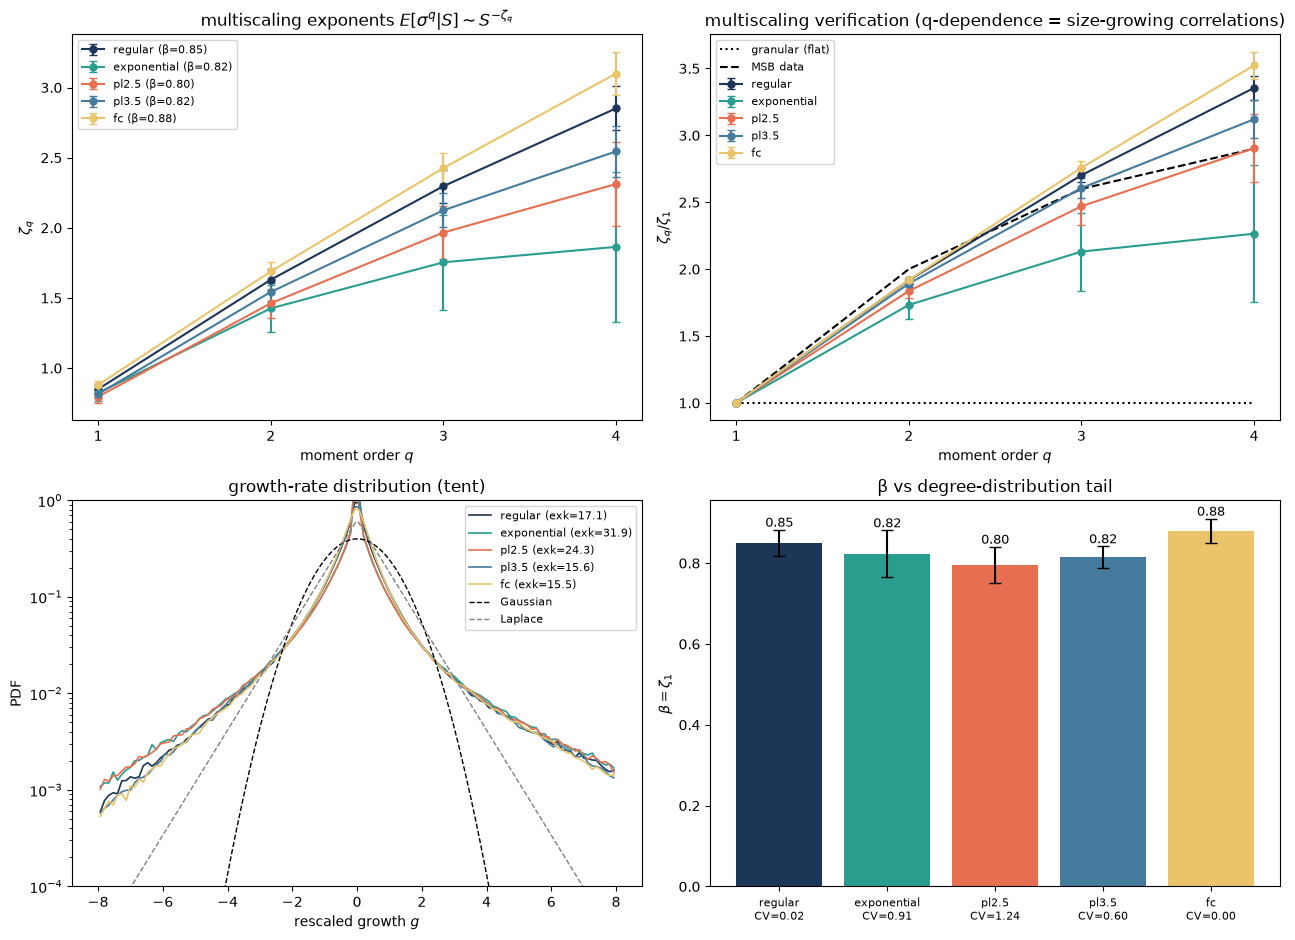

In [6]:
# ---- figures --------------------------------------------------------------------------------
cols = {"regular": "#1d3557", "exponential": "#2a9d8f", "pl2.5": "#e76f51",
        "pl3.5": "#457b9d", "fc": "#e9c46a"}
qs = np.array([1, 2, 3, 4])
fig, ax = plt.subplots(2, 2, figsize=(13, 9.5))

# (0,0) zeta_q vs q with error bars
for t in TOPOS:
    if t not in results: continue
    ms = results[t]["ms"]
    ax[0, 0].errorbar(qs, ms["cq"], yerr=ms["cq_err"], marker="o", ms=5, capsize=3,
                      color=cols[t], label=f"{t} (β={ms['cq'][0]:.2f})")
ax[0, 0].set(xlabel="moment order $q$", ylabel=r"$\zeta_q$", xticks=qs,
             title=r"multiscaling exponents $E[\sigma^q|S]\sim S^{-\zeta_q}$")
ax[0, 0].legend(fontsize=8)

# (0,1) ratio zeta_q/zeta_1 vs q, with granular + MSB references
for t in TOPOS:
    if t not in results: continue
    ms = results[t]["ms"]
    ax[0, 1].errorbar(qs, ms["ratio"], yerr=ms["ratio_err"], marker="o", ms=5, capsize=3,
                      color=cols[t], label=t)
ax[0, 1].plot(qs, [1, 1, 1, 1], "k:", lw=1.5, label="granular (flat)")
ax[0, 1].plot(qs, [1, 2.0, 2.6, 2.9], "k--", lw=1.5, label="MSB data")
ax[0, 1].set(xlabel="moment order $q$", ylabel=r"$\zeta_q/\zeta_1$", xticks=qs,
             title="multiscaling verification (q-dependence = size-growing correlations)")
ax[0, 1].legend(fontsize=8)

# (1,0) growth tent overlay
zz = np.linspace(-8, 8, 200)
for t in TOPOS:
    if t not in results: continue
    z = results[t]["gz"]
    h, e = np.histogram(z, bins=120, range=(-8, 8), density=True); m = h > 0
    ax[1, 0].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], lw=1.2, color=cols[t],
                      label=f"{t} (exk={results[t]['ts']['exkurt']:.1f})")
ax[1, 0].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[1, 0].semilogy(zz, laplace.pdf(zz, scale=np.sqrt(2 / np.pi)), "0.5", ls="--", lw=1, label="Laplace")
ax[1, 0].set(xlabel=r"rescaled growth $g$", ylabel="PDF", ylim=(1e-4, 1),
             title="growth-rate distribution (tent)")
ax[1, 0].legend(fontsize=8)

# (1,1) beta = zeta_1 per topology, error bars = bootstrap; annotate degree CV
names = [t for t in TOPOS if t in results]
bx = np.arange(len(names))
betas = [results[t]["ms"]["cq"][0] for t in names]
berr = [results[t]["ms"]["cq_err"][0] for t in names]
ax[1, 1].bar(bx, betas, yerr=berr, capsize=4, color=[cols[t] for t in names])
ax[1, 1].set(xticks=bx, ylabel=r"$\beta=\zeta_1$", title="β vs degree-distribution tail")
ax[1, 1].set_xticklabels([f"{t}\nCV={results[t]['kcv']:.2f}" for t in names], fontsize=8)
for i, (b, ee) in enumerate(zip(betas, berr)):
    ax[1, 1].text(i, b + ee, f"{b:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("data/topology_multiscaling.png", dpi=120)
plt.show()

In [7]:
# ---- persist the aggregates so this can be replotted without re-integrating -----------------
save = {}
for t in TOPOS:
    if t not in results: continue
    R = results[t]
    save[f"{t}_cq"] = R["ms"]["cq"]; save[f"{t}_cqerr"] = R["ms"]["cq_err"]
    save[f"{t}_ratio"] = R["ms"]["ratio"]; save[f"{t}_ratioerr"] = R["ms"]["ratio_err"]
    save[f"{t}_beta_each"] = R["beta_each"]; save[f"{t}_kcv"] = R["kcv"]
    save[f"{t}_bowley"] = R["ts"]["bowley"]; save[f"{t}_exk"] = R["ts"]["exkurt"]
    save[f"{t}_gz"] = R["gz"][::max(1, R["gz"].size // 40000)].astype(np.float32)
np.savez("data/topology_multiscaling.npz", N=N, seeds=SEEDS, topos=np.array(TOPOS), **save)
print("saved data/topology_multiscaling.npz and data/topology_multiscaling.png")

saved data/topology_multiscaling.npz and data/topology_multiscaling.png


## Reading

- **ζ₁ (=β) across the topologies** answers, robustly this time, whether the degree-distribution
  tail moves the size–volatility exponent. Overlapping error bars → topology-independent (the
  earlier "topology moves β" was 4-seed noise). Separated bars that track the CV column → the tail
  genuinely reshapes β through the collective state.
- **ζ_q/ζ₁ vs q** is the multiscaling test. Rising with q and near the MSB dashed line → the model
  reproduces the size-growing correlations; flat near the granular line → it doesn't. Compare the
  curves across topologies: does the heavy tail help or hurt the multiscaling?
- **The tents** show whether the fat-tailed growth distribution survives in each topology and how
  its excess kurtosis shifts.
- **fc (dense, no topology)** is the control: if it multiscales like the sparse graphs, the graph
  merely *modulates* an effect the pure disorder already produces; if fc is granular/weak, the sparse
  structure (finite connectivity, the non-Gaussian few-neighbour field) is *essential*.

pl2.5 is the thesis column; read the others as counterfactuals against it.
**Caveat:** the ζ_q absolutes are N/sample-fragile (own-degree ζ₄/ζ₁ read 2.9–3.5 across runs); trust
the *ordering / curve shape* across topologies more than the exact numbers.